# Experimento 07 (baseline/Ga+Ju+Si)

Investigar a existência de agrupamentos naturais nos dados biomecânicos da marcha do subconjunto Ga, Ju e Si utilizando K-Means sem redução dimensional.

# 1. Importando as bibliotecas

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from google.colab import drive

# 2. Montando o Google Drive

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3. Carregando o Dataset Baseline

In [3]:
BASE_PATH = Path('/content/drive/MyDrive/results')

ga_file = BASE_PATH / 'ga_baseline_features.csv'
ju_file = BASE_PATH / 'ju_baseline_features.csv'
si_file = BASE_PATH / 'si_baseline_features.csv'

ga_df = pd.read_csv(ga_file)
ju_df = pd.read_csv(ju_file)
si_df = pd.read_csv(si_file)

In [4]:
combined_df = pd.concat(
    [ga_df, ju_df, si_df],
    ignore_index=True
)

In [5]:
combined_df.shape

(306, 12)

In [6]:
combined_df.head()

,dataset,patient_id,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
0,Ga,GaPt24_10,473.238435,502.094442,411.342104,422.206326,0.869207,0.840890,-28.856007,28.856007,1188.55,1210.77
1,Ga,GaCo09_02,470.210635,423.825689,409.763042,374.653720,0.871446,0.883981,46.384946,46.384946,1151.26,983.62
2,Ga,GaPt14_10,540.243175,425.180815,461.761851,389.215544,0.854730,0.915412,115.062360,115.062360,1276.00,1092.96
3,Ga,GaPt08_02,391.887131,419.585864,340.767717,370.100560,0.869556,0.882062,-27.698733,27.698733,904.86,927.74
4,Ga,GaPt28_10,591.748944,593.337949,488.596962,482.026601,0.825683,0.812398,-1.589005,1.589005,1324.84,1342.77


In [7]:
combined_df.info()
combined_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dataset          306 non-null    object 
 1   patient_id       306 non-null    object 
 2   mean_total_L     306 non-null    float64
 3   mean_total_R     306 non-null    float64
 4   std_total_L      306 non-null    float64
 5   std_total_R      306 non-null    float64
 6   cv_total_L       306 non-null    float64
 7   cv_total_R       306 non-null    float64
 8   assimetria_mean  306 non-null    float64
 9   assimetria_abs   306 non-null    float64
 10  peak_force_L     306 non-null    float64
 11  peak_force_R     306 non-null    float64
dtypes: float64(10), object(2)
memory usage: 28.8+ KB


,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
count,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000
mean,455.540834,455.615206,393.091673,393.661727,0.864393,0.865259,-0.074372,27.824068,1079.302386,1072.418399
std,75.007121,69.187154,63.205005,58.478342,0.039517,0.035025,37.581730,25.212596,179.959258,172.433768
min,257.118875,251.897876,226.298854,224.369987,0.638924,0.733060,-104.968020,0.159885,679.360000,662.200000
25%,403.513902,417.984249,351.562338,359.352392,0.841747,0.845643,-20.445337,9.363647,954.305000,965.745000
50%,461.024547,458.535856,390.373049,395.155261,0.866278,0.866220,1.498865,20.333072,1053.965000,1057.320000
75%,495.804085,500.247280,435.968010,434.506717,0.885182,0.883863,19.872341,39.430679,1208.542500,1182.692500
max,687.630032,702.366501,612.168131,634.996815,1.178253,1.163285,122.906652,122.906652,1816.540000,1911.030000


# 4. Defininção das features

Removendo colunas não utilizadas no clustering

In [8]:
feature_cols = [
    'mean_total_L',
    'mean_total_R',

    'std_total_L',
    'std_total_R',

    'cv_total_L',
    'cv_total_R',

    'assimetria_mean',
    'assimetria_abs',

    'peak_force_L',
    'peak_force_R'
]

X = combined_df[feature_cols]

# 5. Normalização dos dados

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 6. Escolha do número de clusters

## Elbow Method

In [10]:
inertia = []

k_values = range(2, 7)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

Visualizando o Elbow Method

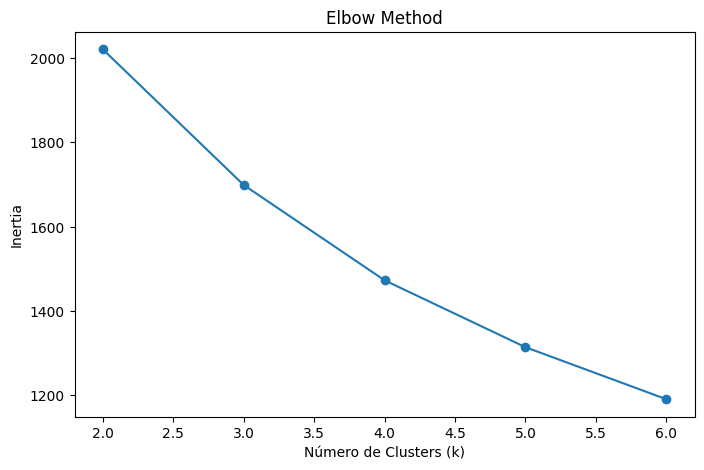

In [11]:
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inertia')

plt.show()

# 7. Avaliação com Silhouette Score

In [12]:
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f'k={k} | Silhouette Score: {score:.4f}')

k=2 | Silhouette Score: 0.3028
k=3 | Silhouette Score: 0.2315
k=4 | Silhouette Score: 0.2618
k=5 | Silhouette Score: 0.2290
k=6 | Silhouette Score: 0.2452


Vizualização com o Silhouette Score

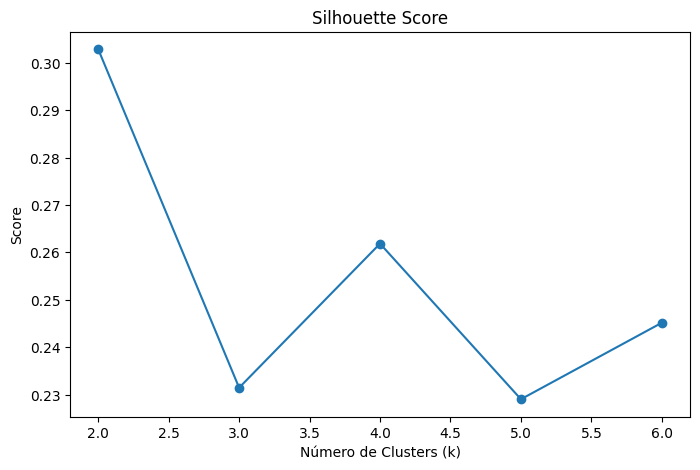

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Score')

plt.show()

# 8. Treinamento final com o K-Means

In [14]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

Adicionando clusters ao dataframe

In [15]:
combined_df['cluster'] = clusters

combined_df.head()

,dataset,patient_id,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R,cluster
0,Ga,GaPt24_10,473.238435,502.094442,411.342104,422.206326,0.869207,0.840890,-28.856007,28.856007,1188.55,1210.77,1
1,Ga,GaCo09_02,470.210635,423.825689,409.763042,374.653720,0.871446,0.883981,46.384946,46.384946,1151.26,983.62,0
2,Ga,GaPt14_10,540.243175,425.180815,461.761851,389.215544,0.854730,0.915412,115.062360,115.062360,1276.00,1092.96,1
3,Ga,GaPt08_02,391.887131,419.585864,340.767717,370.100560,0.869556,0.882062,-27.698733,27.698733,904.86,927.74,0
4,Ga,GaPt28_10,591.748944,593.337949,488.596962,482.026601,0.825683,0.812398,-1.589005,1.589005,1324.84,1342.77,1


# 9. Métricas Internas

In [16]:
silhouette = silhouette_score(
    X_scaled,
    clusters
)

davies = davies_bouldin_score(
    X_scaled,
    clusters
)

calinski = calinski_harabasz_score(
    X_scaled,
    clusters
)

print(f'Silhouette Score: {silhouette:.4f}')
print(f'Davies-Bouldin Index: {davies:.4f}')
print(f'Calinski-Harabasz Score: {calinski:.4f}')

Silhouette Score: 0.3028
Davies-Bouldin Index: 1.2361
Calinski-Harabasz Score: 156.4609


# 10. Visualização dos Clusters

PCA somente usado para visualização

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

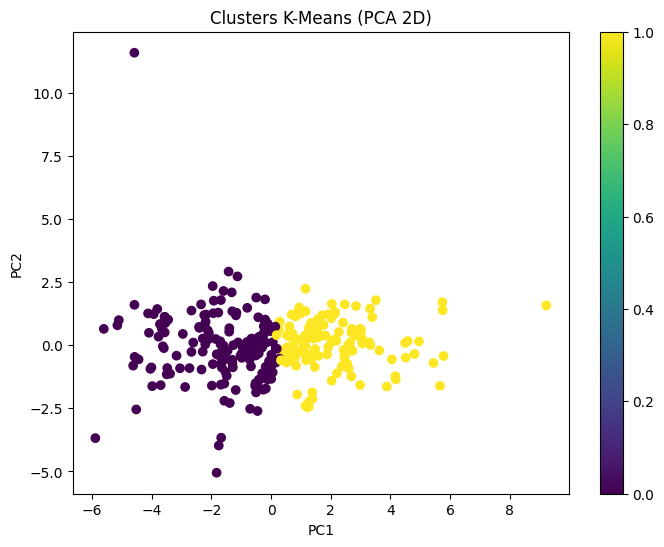

In [18]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.title('Clusters K-Means (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.colorbar(scatter)

plt.show()

# 11. HeatMap dos centroídes

In [19]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=feature_cols
)

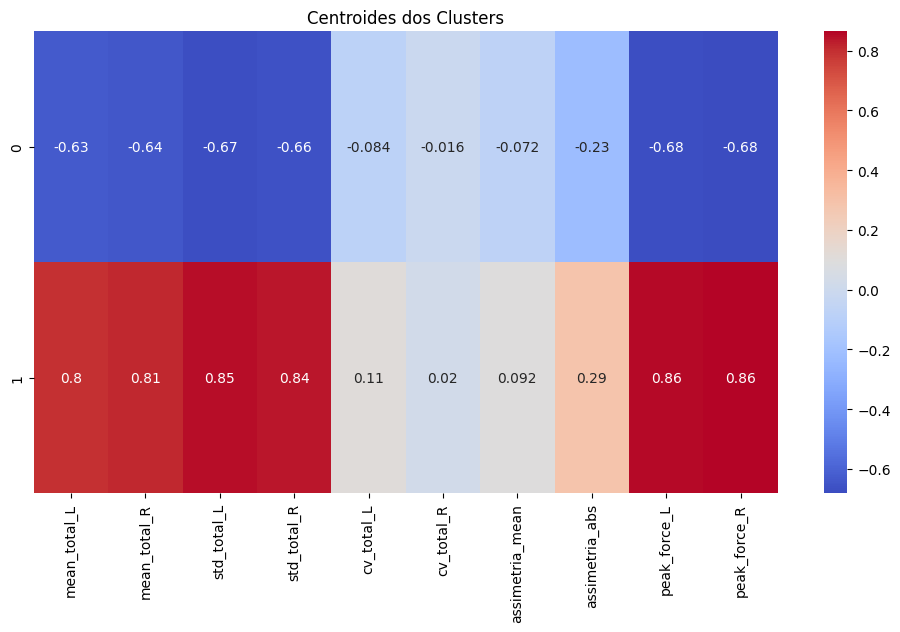

In [20]:
plt.figure(figsize=(12,6))

sns.heatmap(
    centroids,
    annot=True,
    cmap='coolwarm'
)

plt.title('Centroides dos Clusters')

plt.show()

# 12. Distribuição dos Clusters

In [21]:
combined_df['cluster'].value_counts()

,count
cluster,
0,171
1,135


# 13. Composição dos clusters por dataset

In [22]:
combined_df.groupby('cluster')['dataset'].value_counts()

cluster  dataset
0        Ju         73
         Ga         69
         Si         29
1        Ju         56
         Ga         44
         Si         35
Name: count, dtype: int64

# 14. Média das features por cluster e dataset

In [23]:
combined_df.groupby(
    ['cluster', 'dataset']
)[feature_cols].mean()

mean_total_L  mean_total_R  std_total_L  std_total_R  \
cluster dataset                                                         
0       Ga         405.760826    410.135524   346.323378   354.231905   
        Ju         413.388515    413.628435   355.130031   356.731743   
        Si         402.625950    408.090941   350.130028   352.128832   
1       Ga         535.057432    520.681067   459.532017   448.149345   
        Ju         509.362932    513.932009   442.800699   445.157009   
        Si         499.360940    497.120839   437.006511   431.942001   

                 cv_total_L  cv_total_R  assimetria_mean  assimetria_abs  \
cluster dataset                                                            
0       Ga         0.856886    0.865783        -4.374698       25.956005   
        Ju         0.861091    0.863770        -0.239920       18.599354   
        Si         0.870997    0.864561        -5.464991       22.025688   
1       Ga         0.860128    0.862033        14.376364       35.866359   
        Ju         0.870902    0.867045        -4.569077       39.586996   
        Si         0.875558    0.869107         2.240101       26.620313   

                 peak_force_L  peak_force_R  
cluster dataset                              
0       Ga         947.895507    957.860870  
        Ju         973.626575    956.416849  
        Si         942.385172    944.376552  
1       Ga        1254.207500   1239.952500  
        Ju        1221.872143   1213.358929  
        Si        1224.224571   1210.179143